# Z24 Bridge Anomaly Prediction v2 - 50Hz + Temperature

This notebook trains an improved CNN-LSTM model with:
- **50 Hz sampling** (captures modal frequencies up to 25 Hz)
- **Temperature feature** (deck temperature from EMS environmental sensors)

**Task:** Given 10 seconds of accelerometer + temperature history, predict anomaly probability for the next 60 seconds.

**Changes from v01:**
| Aspect | v01 | v02 |
|--------|-----|-----|
| Sample rate | 10 Hz | 50 Hz |
| Input timesteps | 100 (10s) | 500 (10s) |
| Channels | 5 (accel only) | 6 (5 accel + temp) |
| Nyquist freq | 5 Hz | 25 Hz |

## 1. Setup & Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import os

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve
)

from z24_loader import Z24DataLoader

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

if torch.cuda.is_available():
    device = torch.device('cuda')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

PyTorch version: 2.9.0+cu126
Device: cuda


## 2. Load Data (v2 - 50Hz + Temperature)

In [ ]:
DEMO_PATH = '/content/z24_demo_v2.npz'
data = Z24DataLoader.load_demo_dataset(DEMO_PATH)

X_train, y_train = data['X_train'], data['y_train']
X_val, y_val = data['X_val'], data['y_val']
X_test, y_test = data['X_test'], data['y_test']
config = data['config']

print("Dataset v2 loaded!")
print(f"\nShapes:")
print(f"  X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"  X_val:   {X_val.shape} | y_val:   {y_val.shape}")
print(f"  X_test:  {X_test.shape} | y_test:  {y_test.shape}")
print(f"\nConfig:")
for k, v in config.items():
    print(f"  {k}: {v}")

Dataset v2 loaded!

Shapes:
  X_train: (10953, 500, 6) | y_train: (10953, 30, 1)
  X_val:   (3651, 500, 6) | y_val:   (3651, 30, 1)
  X_test:  (3651, 500, 6) | y_test:  (3651, 30, 1)

Config:
  sample_rate_hz: 50
  original_sample_rate_hz: 100
  input_steps: 500
  output_steps: 3000
  output_sample_rate: 100
  n_output_steps: 30
  channels: ['CH0', 'CH1', 'CH2', 'CH3', 'CH4', 'TEMP']
  include_temp: True
  data_source: EMS+PDT_v2_transitions
  samples_per_class: 100000
  n_segments: 5
  created_at: 2026-01-08T20:05:46.250646


In [ ]:
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train)
X_val_t = torch.FloatTensor(X_val)
y_val_t = torch.FloatTensor(y_val)
X_test_t = torch.FloatTensor(X_test)
y_test_t = torch.FloatTensor(y_test)

BATCH_SIZE = 128  # Larger batch for more stable gradients

train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"DataLoaders created with batch_size={BATCH_SIZE}")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches:   {len(val_loader)}")
print(f"  Test batches:  {len(test_loader)}")

DataLoaders created with batch_size=128
  Train batches: 86
  Val batches:   29
  Test batches:  29


In [ ]:
class TimeSeriesAugmentation:
    @staticmethod
    def add_noise(x, noise_factor=0.05):
        noise = torch.randn_like(x) * noise_factor
        return x + noise

    @staticmethod
    def scale(x, scale_range=(0.8, 1.2)):
        scale = np.random.uniform(*scale_range)
        return x * scale

    @staticmethod
    def channel_dropout(x, p=0.1):
        if np.random.random() < p:
            ch = np.random.randint(0, min(5, x.shape[2]))
            x = x.clone()
            x[:, :, ch] = 0
        return x

print("TimeSeriesAugmentation class defined.")

TimeSeriesAugmentation class defined.


## 3. Model Architecture (v2 - Deeper CNN for 50Hz)

In [ ]:
class CNNLSTMv2(nn.Module):
    """
    Improved CNN-LSTM for 50Hz data with separate pathways for accelerometer and temperature.

    Architecture:
    - Accelerometer (5 channels): CNN -> LSTM -> features
    - Temperature (1 channel): Small MLP -> features
    - Concatenate both feature vectors -> Final classification

    Changes from previous version:
    - Separate processing paths for accelerometer and temperature
    - Temperature processed through dedicated MLP
    - Features concatenated before final FC layer
    """
    def __init__(self, n_accel_features=5, hidden_size=64, output_steps=30, dropout=0.4):
        super().__init__()

        # CNN layers for accelerometer data (5 channels)
        self.conv1 = nn.Conv1d(n_accel_features, 32, kernel_size=7, padding=3)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.conv3 = nn.Conv1d(64, 128, kernel_size=3, padding=1)

        self.bn1 = nn.BatchNorm1d(32)
        self.bn2 = nn.BatchNorm1d(64)
        self.bn3 = nn.BatchNorm1d(128)

        self.pool = nn.MaxPool1d(2)
        self.dropout = nn.Dropout(dropout)

        # LSTM for accelerometer temporal features
        self.lstm = nn.LSTM(128, hidden_size, num_layers=2, batch_first=True, dropout=dropout)
        self.accel_layer_norm = nn.LayerNorm(hidden_size)

        # MLP for temperature data (processes scalar per timestep -> single feature vector)
        temp_hidden = 16
        self.temp_mlp = nn.Sequential(
            nn.Linear(1, temp_hidden),
            nn.ReLU(),
            nn.Linear(temp_hidden, temp_hidden),
            nn.ReLU(),
        )
        self.temp_layer_norm = nn.LayerNorm(temp_hidden)

        # Final classification layer (concatenated features)
        self.fc = nn.Linear(hidden_size + temp_hidden, output_steps)
        self.output_steps = output_steps

    def forward(self, x):
        # Split accelerometer and temperature
        # x: (batch, seq_len, features) where features = 5 accel + 1 temp
        x_accel = x[:, :, :5]  # (batch, seq_len, 5)
        x_temp = x[:, :, 5:6]  # (batch, seq_len, 1)

        # === Accelerometer pathway (CNN-LSTM) ===
        # (batch, seq_len, features) -> (batch, features, seq_len)
        x_accel = x_accel.permute(0, 2, 1)

        # CNN feature extraction
        x_accel = F.relu(self.bn1(self.conv1(x_accel)))
        x_accel = self.pool(x_accel)  # 500 -> 250
        x_accel = self.dropout(x_accel)

        x_accel = F.relu(self.bn2(self.conv2(x_accel)))
        x_accel = self.pool(x_accel)  # 250 -> 125
        x_accel = self.dropout(x_accel)

        x_accel = F.relu(self.bn3(self.conv3(x_accel)))
        x_accel = self.pool(x_accel)  # 125 -> 62
        x_accel = self.dropout(x_accel)

        # LSTM: (batch, features, seq) -> (batch, seq, features)
        x_accel = x_accel.permute(0, 2, 1)
        lstm_out, _ = self.lstm(x_accel)

        # Use last hidden state with layer norm
        accel_features = lstm_out[:, -1, :]  # (batch, hidden_size)
        accel_features = self.accel_layer_norm(accel_features)
        accel_features = self.dropout(accel_features)

        # === Temperature pathway (MLP) ===
        # Use mean temperature over the sequence as input
        x_temp_mean = x_temp.mean(dim=1)  # (batch, 1)
        temp_features = self.temp_mlp(x_temp_mean)  # (batch, temp_hidden)
        temp_features = self.temp_layer_norm(temp_features)
        temp_features = self.dropout(temp_features)

        # === Concatenate and classify ===
        combined = torch.cat([accel_features, temp_features], dim=1)  # (batch, hidden_size + temp_hidden)
        out = torch.sigmoid(self.fc(combined))
        return out.unsqueeze(-1)

N_ACCEL_FEATURES = 5  # Accelerometer channels only
HIDDEN_SIZE = 64
OUTPUT_STEPS = y_train.shape[1]
DROPOUT = 0.4

model = CNNLSTMv2(
    n_accel_features=N_ACCEL_FEATURES,
    hidden_size=HIDDEN_SIZE,
    output_steps=OUTPUT_STEPS,
    dropout=DROPOUT
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model created!")
print(f"  Total parameters: {total_params:,}")
print(f"\nArchitecture:")
print(model)

Model created!
  Total parameters: 122,446

Architecture:
CNNLSTMv2(
  (conv1): Conv1d(5, 32, kernel_size=(7,), stride=(1,), padding=(3,))
  (conv2): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
  (conv3): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.4, inplace=False)
  (lstm): LSTM(128, 64, num_layers=2, batch_first=True, dropout=0.4)
  (accel_layer_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (temp_mlp): Sequential(
    (0): Linear(in_features=1, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
 

## 4. Training

In [ ]:
LEARNING_RATE = 1e-3
EPOCHS = 80
PATIENCE = 25

criterion = nn.BCELoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-2)

# OneCycleLR - smooth single ramp, no restarts
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=LEARNING_RATE,
    epochs=EPOCHS,
    steps_per_epoch=len(train_loader),
    pct_start=0.3,  # 30% warmup
    anneal_strategy='cos',
    div_factor=25,  # Initial LR = max_lr/25
    final_div_factor=1000  # Final LR = max_lr/1000
)

print(f"Training configuration:")
print(f"  Max learning rate: {LEARNING_RATE}")
print(f"  Weight decay: 1e-2")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Scheduler: OneCycleLR (30% warmup, cosine anneal)")
print(f"  Epochs: {EPOCHS}")
print(f"  Early stopping patience: {PATIENCE}")

Training configuration:
  Max learning rate: 0.001
  Weight decay: 1e-2
  Batch size: 128
  Scheduler: OneCycleLR (30% warmup, cosine anneal)
  Epochs: 80
  Early stopping patience: 25


In [ ]:
def train_epoch(model, loader, criterion, optimizer, scheduler, device, augment=True):
    model.train()
    total_loss = 0
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        if augment:
            X_batch = TimeSeriesAugmentation.add_noise(X_batch, 0.03)  # Reduced noise
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()  # Step per batch for OneCycleLR
        total_loss += loss.item() * X_batch.size(0)
    return total_loss / len(loader.dataset)

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            total_loss += loss.item() * X_batch.size(0)
            all_preds.append(outputs.cpu().numpy())
            all_targets.append(y_batch.cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    all_preds = np.concatenate(all_preds, axis=0)
    all_targets = np.concatenate(all_targets, axis=0)
    return avg_loss, all_preds, all_targets

print("Training functions defined.")

Training functions defined.


In [ ]:
print("=" * 60)
print("TRAINING (v2 - 50Hz + Temperature - Stable Training)")
print("=" * 60)

train_losses = []
val_losses = []
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

for epoch in range(EPOCHS):
    train_loss = train_epoch(model, train_loader, criterion, optimizer, scheduler, device, augment=True)
    train_losses.append(train_loss)
    val_loss, _, _ = evaluate(model, val_loader, criterion, device)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = model.state_dict().copy()
        marker = " *"
    else:
        patience_counter += 1
        marker = ""

    if epoch < 10 or (epoch + 1) % 5 == 0:
        gap = val_loss - train_loss
        lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | Train: {train_loss:.4f} | Val: {val_loss:.4f} | Gap: {gap:+.4f} | LR: {lr:.2e}{marker}")

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+1}!")
        break

if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"\nRestored best model with val_loss={best_val_loss:.4f}")

TRAINING (v2 - 50Hz + Temperature - Stable Training)
Epoch   1/80 | Train: 0.6179 | Val: 0.4849 | Gap: -0.1330 | LR: 4.41e-05 *
Epoch   2/80 | Train: 0.4420 | Val: 0.3542 | Gap: -0.0878 | LR: 5.64e-05 *
Epoch   3/80 | Train: 0.3339 | Val: 0.2725 | Gap: -0.0614 | LR: 7.66e-05 *
Epoch   4/80 | Train: 0.2603 | Val: 0.2205 | Gap: -0.0398 | LR: 1.04e-04 *
Epoch   5/80 | Train: 0.2128 | Val: 0.1903 | Gap: -0.0225 | LR: 1.39e-04 *
Epoch   6/80 | Train: 0.1842 | Val: 0.1740 | Gap: -0.0102 | LR: 1.81e-04 *
Epoch   7/80 | Train: 0.1680 | Val: 0.1644 | Gap: -0.0036 | LR: 2.28e-04 *
Epoch   8/80 | Train: 0.1604 | Val: 0.1580 | Gap: -0.0025 | LR: 2.80e-04 *
Epoch   9/80 | Train: 0.1547 | Val: 0.1535 | Gap: -0.0012 | LR: 3.37e-04 *
Epoch  10/80 | Train: 0.1502 | Val: 0.1516 | Gap: +0.0014 | LR: 3.96e-04 *
Epoch  15/80 | Train: 0.1413 | Val: 0.1451 | Gap: +0.0038 | LR: 7.04e-04 *
Epoch  20/80 | Train: 0.1355 | Val: 0.1299 | Gap: -0.0056 | LR: 9.36e-04 *
Epoch  25/80 | Train: 0.1117 | Val: 0.0974 | Ga

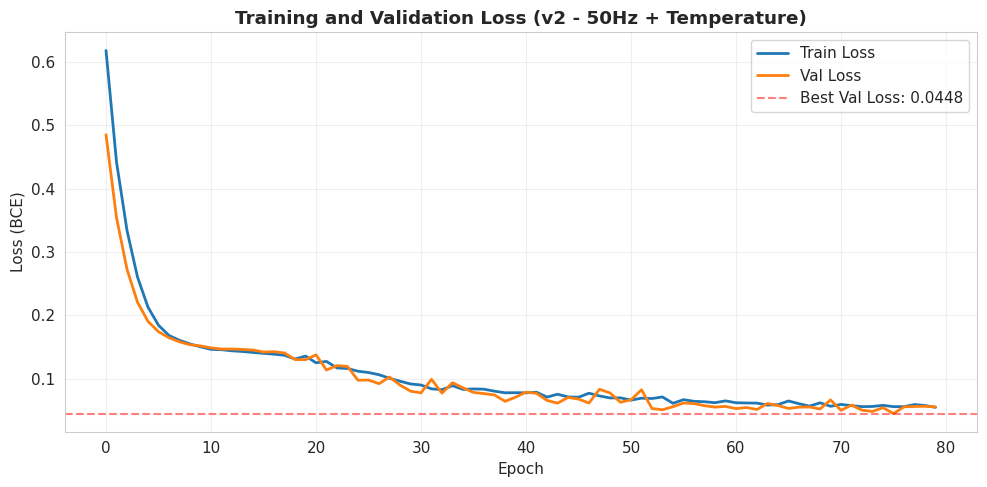

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_losses, label='Train Loss', linewidth=2)
ax.plot(val_losses, label='Val Loss', linewidth=2)
ax.axhline(y=best_val_loss, color='r', linestyle='--', alpha=0.5, label=f'Best Val Loss: {best_val_loss:.4f}')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (BCE)')
ax.set_title('Training and Validation Loss (v2 - 50Hz + Temperature)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Evaluation

In [ ]:
def compute_metrics(y_true, y_pred, threshold=0.5):
    y_true_flat = y_true.flatten()
    y_pred_flat = y_pred.flatten()
    y_pred_binary = (y_pred_flat >= threshold).astype(int)
    metrics = {
        'accuracy': accuracy_score(y_true_flat, y_pred_binary),
        'precision': precision_score(y_true_flat, y_pred_binary, zero_division=0),
        'recall': recall_score(y_true_flat, y_pred_binary, zero_division=0),
        'f1': f1_score(y_true_flat, y_pred_binary, zero_division=0),
        'auc_roc': roc_auc_score(y_true_flat, y_pred_flat),
    }
    return metrics

test_loss, test_preds, test_targets = evaluate(model, test_loader, criterion, device)

print("=" * 60)
print("TEST SET EVALUATION (v2)")
print("=" * 60)
print(f"\nTest Loss: {test_loss:.4f}")

metrics = compute_metrics(test_targets, test_preds)

print(f"\nClassification Metrics (threshold=0.5):")
print(f"  Accuracy:  {metrics['accuracy']:.4f}")
print(f"  Precision: {metrics['precision']:.4f}")
print(f"  Recall:    {metrics['recall']:.4f}")
print(f"  F1 Score:  {metrics['f1']:.4f}")
print(f"  AUC-ROC:   {metrics['auc_roc']:.4f}")

TEST SET EVALUATION (v2)

Test Loss: 0.0648

Classification Metrics (threshold=0.5):
  Accuracy:  0.9774
  Precision: 0.9861
  Recall:    0.9707
  F1 Score:  0.9783
  AUC-ROC:   0.9967


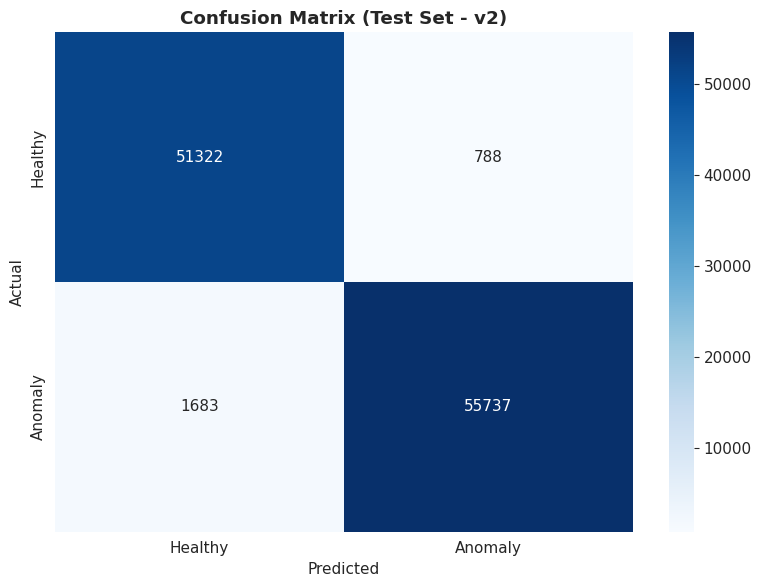


Confusion Matrix Details:
  True Negatives:  51,322
  False Positives: 788
  False Negatives: 1,683
  True Positives:  55,737


In [ ]:
y_true_flat = test_targets.flatten()
y_pred_binary = (test_preds.flatten() >= 0.5).astype(int)
cm = confusion_matrix(y_true_flat, y_pred_binary)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Healthy', 'Anomaly'],
            yticklabels=['Healthy', 'Anomaly'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix (Test Set - v2)', fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion Matrix Details:")
print(f"  True Negatives:  {tn:,}")
print(f"  False Positives: {fp:,}")
print(f"  False Negatives: {fn:,}")
print(f"  True Positives:  {tp:,}")

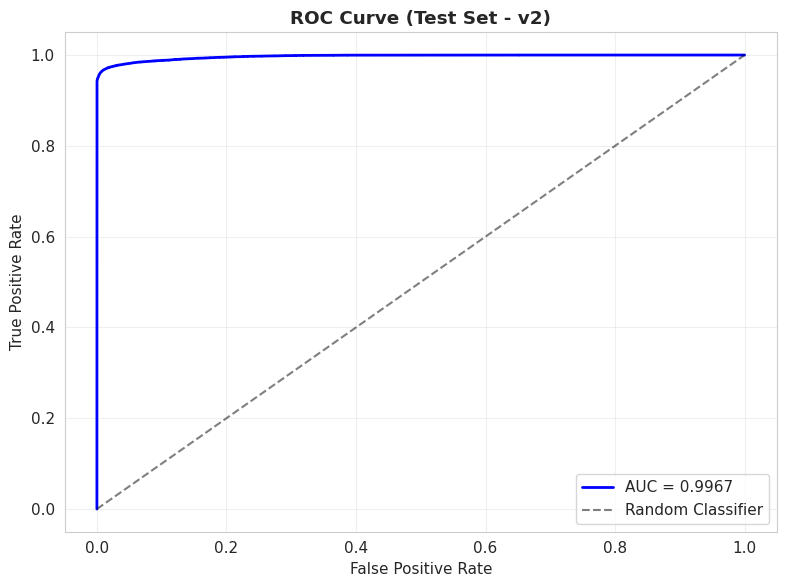

In [ ]:
fpr, tpr, thresholds = roc_curve(y_true_flat, test_preds.flatten())

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, 'b-', linewidth=2, label=f"AUC = {metrics['auc_roc']:.4f}")
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve (Test Set - v2)', fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Frequency Analysis (50Hz Advantage)

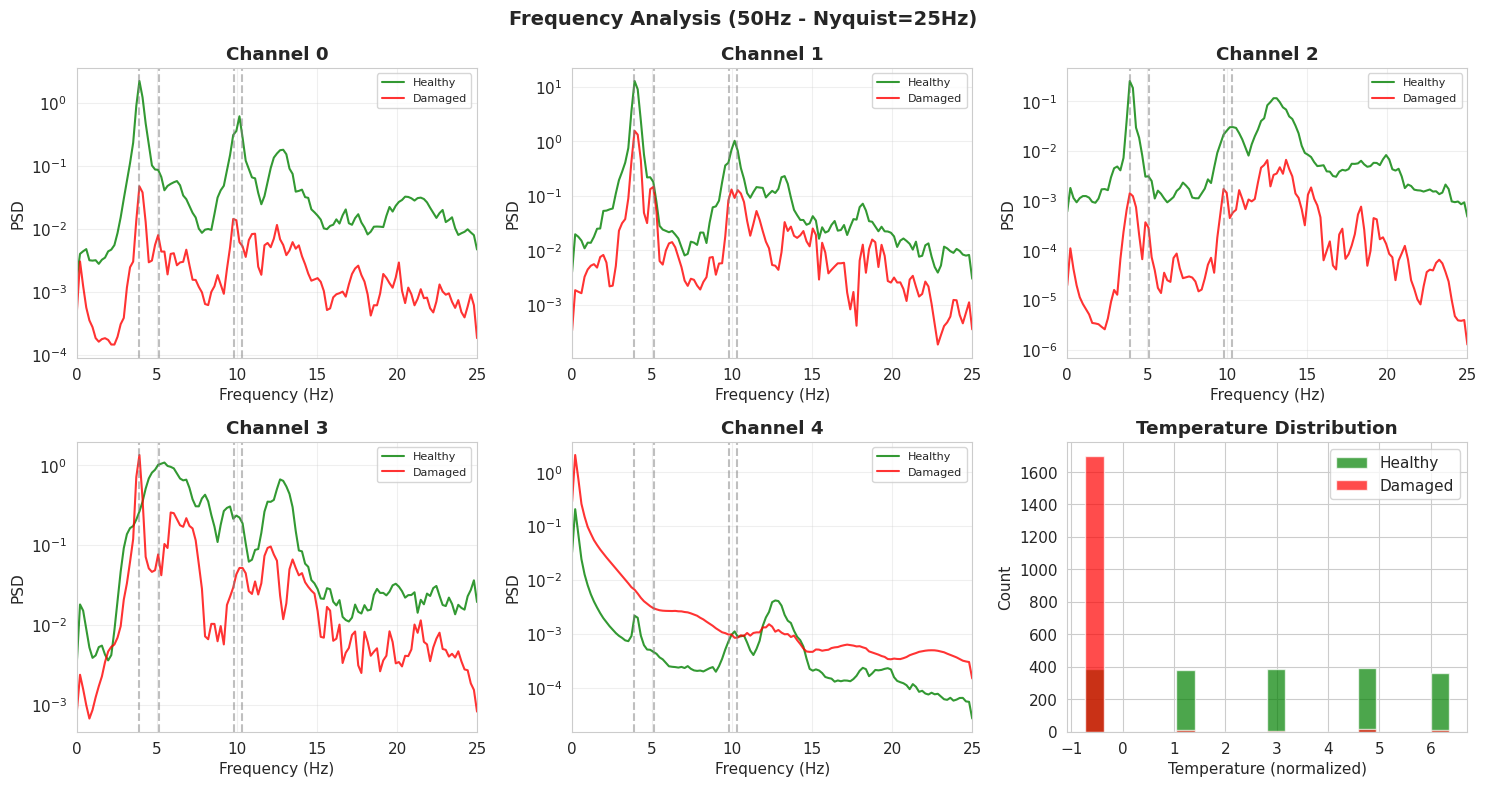


With 50Hz sampling, we can see frequencies up to 25Hz
Modal frequencies from paper: ~3.9, 5.1, 9.8, 10.3 Hz


In [ ]:
from scipy import signal

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

healthy_mask = y_test[:, 0, 0] == 0
damaged_mask = y_test[:, 0, 0] == 1

healthy_idx = np.where(healthy_mask)[0][:100] if healthy_mask.any() else []
damaged_idx = np.where(damaged_mask)[0][:100] if damaged_mask.any() else []

fs = config['sample_rate_hz']

for ch in range(min(5, X_test.shape[2])):
    ax = axes[ch]
    if len(healthy_idx) > 0:
        healthy_data = X_test[healthy_idx, :, ch].flatten()
        f_h, psd_h = signal.welch(healthy_data, fs=fs, nperseg=256)
        ax.semilogy(f_h, psd_h, 'g-', label='Healthy', alpha=0.8)
    if len(damaged_idx) > 0:
        damaged_data = X_test[damaged_idx, :, ch].flatten()
        f_d, psd_d = signal.welch(damaged_data, fs=fs, nperseg=256)
        ax.semilogy(f_d, psd_d, 'r-', label='Damaged', alpha=0.8)
    modal_freqs = [3.9, 5.1, 9.8, 10.3]
    for mf in modal_freqs:
        if mf < fs/2:
            ax.axvline(x=mf, color='gray', linestyle='--', alpha=0.5)
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('PSD')
    ax.set_title(f'Channel {ch}', fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 25)

ax = axes[5]
if X_test.shape[2] > 5:
    temp_data = X_test[:, 0, 5]
    ax.hist(temp_data[healthy_mask], bins=20, alpha=0.7, label='Healthy', color='green')
    ax.hist(temp_data[damaged_mask], bins=20, alpha=0.7, label='Damaged', color='red')
    ax.set_xlabel('Temperature (normalized)')
    ax.set_ylabel('Count')
    ax.set_title('Temperature Distribution', fontweight='bold')
    ax.legend()

plt.suptitle('Frequency Analysis (50Hz - Nyquist=25Hz)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nWith 50Hz sampling, we can see frequencies up to 25Hz")
print(f"Modal frequencies from paper: ~3.9, 5.1, 9.8, 10.3 Hz")

## 7. Save Model

In [ ]:
MODEL_DIR = '/home/yanni/models'
os.makedirs(MODEL_DIR, exist_ok=True)

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
model_path = f"{MODEL_DIR}/z24_cnn_lstm_v2_{timestamp}.pt"

checkpoint = {
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'config': {
        'n_features': 100,
        'hidden_size': HIDDEN_SIZE,
        'output_steps': OUTPUT_STEPS,
        'dropout': DROPOUT,
        'sample_rate_hz': config['sample_rate_hz'],
        'input_steps': config['input_steps'],
    },
    'metrics': metrics,
    'train_losses': train_losses,
    'val_losses': val_losses,
    'best_val_loss': best_val_loss,
}

torch.save(checkpoint, model_path)
print(f"Model saved to: {model_path}")
print(f"File size: {os.path.getsize(model_path) / 1024:.1f} KB")

Model saved to: /home/yanni/models/z24_cnn_lstm_v2_20260115_091659.pt
File size: 1477.9 KB


## 8. Summary

In [ ]:
print("=" * 60)
print("TRAINING SUMMARY (v2 - 50Hz + Temperature)")
print("=" * 60)
print(f"""
Model: CNNLSTMv2
  - Parameters: {total_params:,}
  - Hidden size: {HIDDEN_SIZE}
  - Dropout: {DROPOUT}
  - Input: {config['input_steps']} timesteps x {100} channels

Data:
  - Sample rate: {config['sample_rate_hz']} Hz (Nyquist: {config['sample_rate_hz']//2} Hz)
  - Channels: {config['channels']}
  - Train sequences: {len(X_train):,}

Training:
  - Epochs trained: {len(train_losses)}
  - Best val loss: {best_val_loss:.4f}
  - Final train loss: {train_losses[-1]:.4f}

Test Performance:
  - Accuracy:  {metrics['accuracy']:.4f}
  - Precision: {metrics['precision']:.4f}
  - Recall:    {metrics['recall']:.4f}
  - F1 Score:  {metrics['f1']:.4f}
  - AUC-ROC:   {metrics['auc_roc']:.4f}

Model saved: {model_path}
""")
print("=" * 60)

TRAINING SUMMARY (v2 - 50Hz + Temperature)

Model: CNNLSTMv2
  - Parameters: 122,446
  - Hidden size: 64
  - Dropout: 0.4
  - Input: 500 timesteps x 100 channels

Data:
  - Sample rate: 50 Hz (Nyquist: 25 Hz)
  - Channels: ['CH0', 'CH1', 'CH2', 'CH3', 'CH4', 'TEMP']
  - Train sequences: 10,953

Training:
  - Epochs trained: 80
  - Best val loss: 0.0448
  - Final train loss: 0.0546

Test Performance:
  - Accuracy:  0.9774
  - Precision: 0.9861
  - Recall:    0.9707
  - F1 Score:  0.9783
  - AUC-ROC:   0.9967

Model saved: /home/yanni/models/z24_cnn_lstm_v2_20260115_091659.pt



Extracting features...
Running t-SNE on 1000 samples...
Feature shapes: Accel (1000, 64), Labels (1000,)


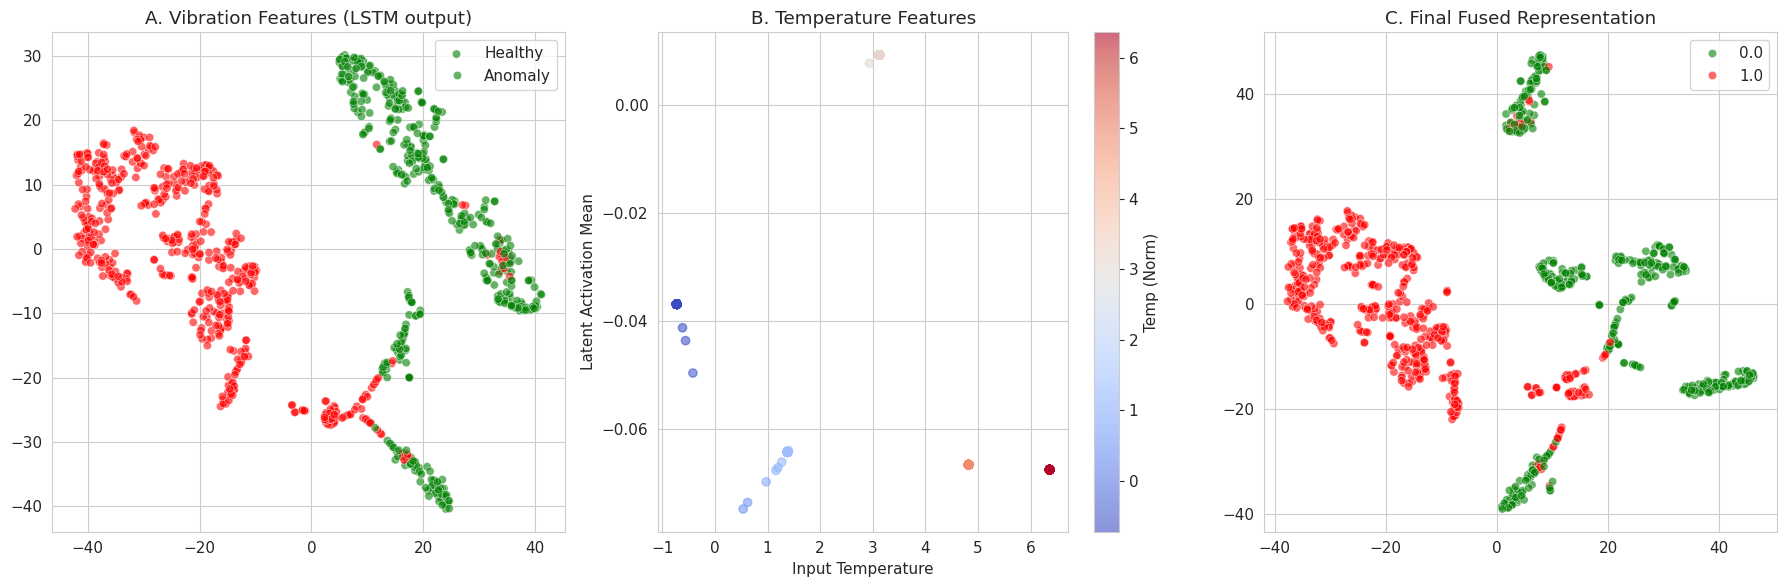

In [21]:
def extract_and_plot_features(model, loader, device, num_samples=1000):
    extractor = FeatureExtractor(model).to(device)
    extractor.eval()

    accel_feats_list = []
    temp_feats_list = []
    combined_feats_list = []
    labels_list = []
    raw_temps_list = []

    print("Extracting features...")
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)

            # Get features
            a_feat, t_feat, c_feat = extractor(X_batch)

            # Store results
            accel_feats_list.append(a_feat.cpu().numpy())
            temp_feats_list.append(t_feat.cpu().numpy())
            combined_feats_list.append(c_feat.cpu().numpy())

            # --- FIX: Collapse labels to one per sequence ---
            # If any timestep in the output window is anomalous (1), mark the whole sample as 1.
            # y_batch shape: (batch, time_steps, 1) -> (batch,)
            seq_labels = y_batch.max(dim=1)[0].squeeze(-1).cpu().numpy()
            labels_list.append(seq_labels)

            # Store raw temperature (mean of first temp channel)
            raw_temps_list.append(X_batch[:, :, 5].mean(dim=1).cpu().numpy())

            # Check length based on concatenated lists so far
            current_count = sum(len(l) for l in labels_list)
            if current_count >= num_samples:
                break

    # Concatenate all batches and truncate to num_samples
    accel_feats = np.concatenate(accel_feats_list)[:num_samples]
    temp_feats = np.concatenate(temp_feats_list)[:num_samples]
    combined_feats = np.concatenate(combined_feats_list)[:num_samples]
    labels = np.concatenate(labels_list)[:num_samples]
    raw_temps = np.concatenate(raw_temps_list)[:num_samples]

    print(f"Running t-SNE on {len(labels)} samples...")
    print(f"Feature shapes: Accel {accel_feats.shape}, Labels {labels.shape}")

    # Run t-SNE
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, init='pca', learning_rate='auto')
    accel_embedded = tsne.fit_transform(accel_feats)
    combined_embedded = tsne.fit_transform(combined_feats)

    # ==========================================
    # 3. Visualization
    # ==========================================
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Plot 1: Accelerometer Features
    sns.scatterplot(
        x=accel_embedded[:, 0], y=accel_embedded[:, 1],
        hue=labels, palette={0: 'green', 1: 'red'}, alpha=0.6, ax=axes[0]
    )
    axes[0].set_title('A. Vibration Features (LSTM output)')
    axes[0].legend(['Healthy', 'Anomaly'])

    # Plot 2: Temperature Features
    temp_magnitude = np.mean(temp_feats, axis=1)
    # Use raw_temps for color to see if latent space organizes by temperature
    sc = axes[1].scatter(raw_temps, temp_magnitude, c=raw_temps, cmap='coolwarm', alpha=0.6)
    axes[1].set_xlabel('Input Temperature')
    axes[1].set_ylabel('Latent Activation Mean')
    axes[1].set_title('B. Temperature Features')
    plt.colorbar(sc, ax=axes[1], label='Temp (Norm)')

    # Plot 3: Combined Features
    sns.scatterplot(
        x=combined_embedded[:, 0], y=combined_embedded[:, 1],
        hue=labels, palette={0: 'green', 1: 'red'}, alpha=0.6, ax=axes[2]
    )
    axes[2].set_title('C. Final Fused Representation')

    plt.tight_layout()
    plt.show()

# Run the visualizer again
extract_and_plot_features(model, test_loader, device)

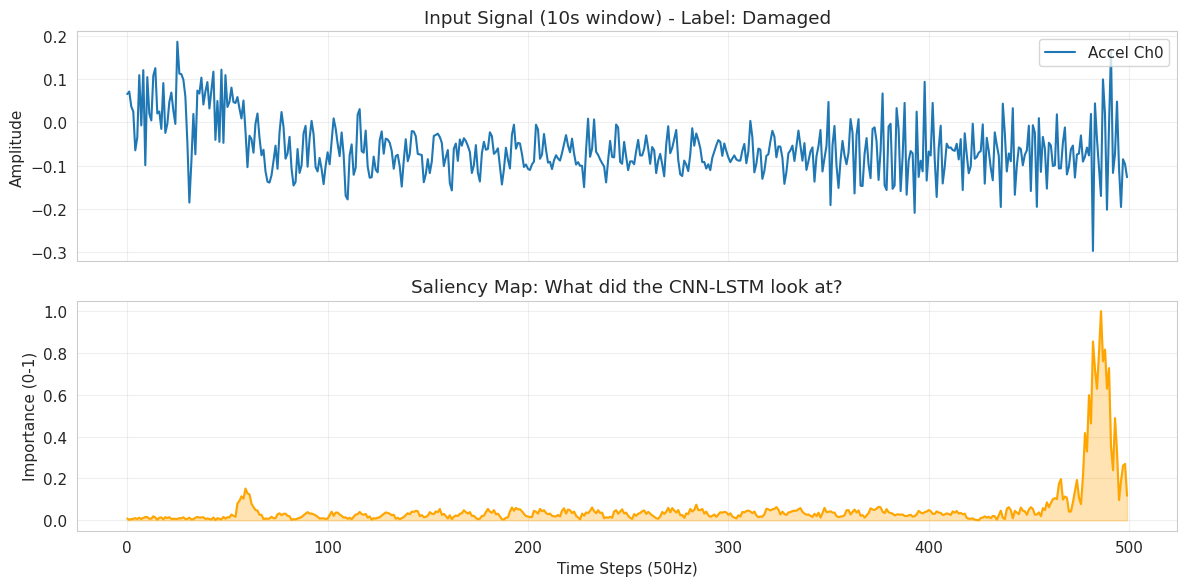

In [23]:
def plot_saliency(model, X_sample, device):
    """
    Computes gradients of the output class with respect to the input.
    Fixes the 'cudnn RNN backward' error by forcing train mode.
    """
    # 1. FIX: Switch to train mode so LSTM allows backward pass
    model.train()

    # 2. OPTIONAL TRICK: Temporarily set dropout to 0 so the map isn't noisy
    # We save the old dropout values to restore them later if needed
    stored_dropouts = []
    for name, m in model.named_modules():
        if isinstance(m, (torch.nn.Dropout, torch.nn.Dropout1d)):
            stored_dropouts.append((m, m.p))
            m.p = 0.0
    # Also handle the internal LSTM dropout
    original_lstm_dropout = model.lstm.dropout
    model.lstm.dropout = 0.0

    # Prepare input
    X = torch.tensor(X_sample).unsqueeze(0).to(device)
    X.requires_grad_()

    # Forward pass
    output = model(X)

    # We want to explain the "Damage" class (index 0)
    score = output[0, 0]
    score.backward()

    # Get gradients
    saliency = X.grad.data.abs().cpu().numpy()[0]  # Shape: (seq_len, channels)

    # Plotting
    fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

    # 1. Original Signal (Accel Channel 0 - Vertical acceleration is usually most interesting)
    # Z24 usually has vertical sensors, let's plot the first one
    ax[0].plot(X_sample[:, 0], label='Accel Ch0')
    ax[0].set_ylabel('Amplitude')
    ax[0].set_title(f"Input Signal (10s window) - Label: Damaged")
    ax[0].legend(loc='upper right')
    ax[0].grid(True, alpha=0.3)

    # 2. Saliency (Importance)
    # Sum saliency across the 5 accelerometer channels to see "global" time importance
    # We exclude the 6th channel (Temp) from this visual to focus on vibration
    saliency_combined = saliency[:, :5].sum(axis=1)

    # Normalize for better visualization
    saliency_combined = (saliency_combined - saliency_combined.min()) / (saliency_combined.max() - saliency_combined.min() + 1e-8)

    ax[1].plot(saliency_combined, color='orange', label='Gradient Importance')
    ax[1].fill_between(range(len(saliency_combined)), 0, saliency_combined, color='orange', alpha=0.3)
    ax[1].set_ylabel('Importance (0-1)')
    ax[1].set_xlabel('Time Steps (50Hz)')
    ax[1].set_title("Saliency Map: What did the CNN-LSTM look at?")
    ax[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # 3. Restore Dropouts (Good practice)
    for m, p in stored_dropouts:
        m.p = p
    model.lstm.dropout = original_lstm_dropout

# Run on a "Damaged" sample
# Find a damaged index
damaged_idx = np.where(y_test[:, 0] == 1)[0][0]
plot_saliency(model, X_test[damaged_idx], device)

Preparing Autoencoder Data...
AE Training Samples (Healthy Only): 5858
AE Test Samples (Mixed): 3651

Training Autoencoder Baseline...
Epoch 5/30 | Loss: 1.187769
Epoch 10/30 | Loss: 0.697682
Epoch 15/30 | Loss: 0.536951
Epoch 20/30 | Loss: 0.466830
Epoch 25/30 | Loss: 0.425781
Epoch 30/30 | Loss: 0.406137


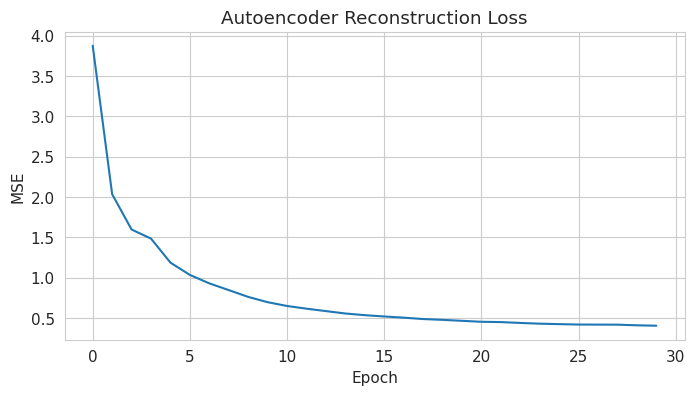


Evaluating...
Autoencoder Baseline AUC-ROC: 0.9976


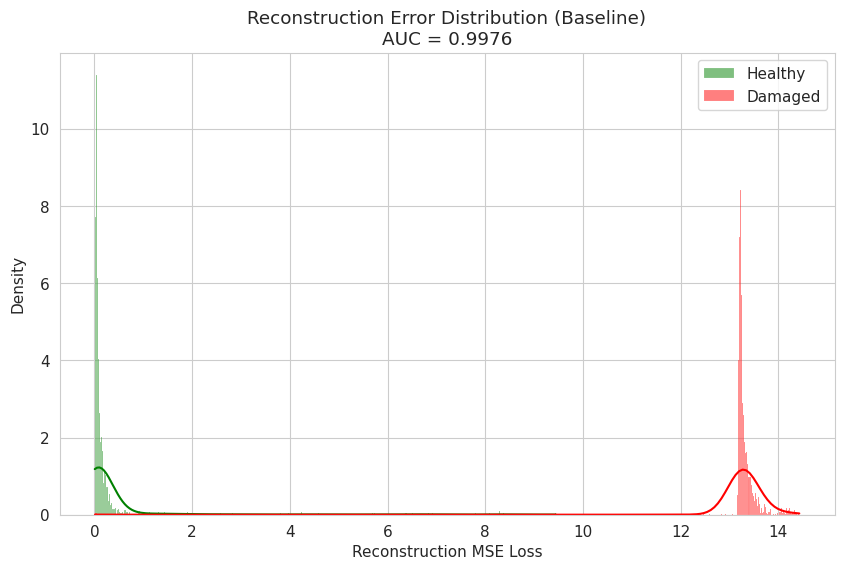

In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader, TensorDataset

# ==========================================
# 1. Prepare Data (Train ONLY on Healthy)
# ==========================================
print("Preparing Autoencoder Data...")

# Filter training data: Keep ONLY Healthy samples (Label == 0)
# We check the first timestep label. If it's 0, the whole sequence is healthy.
healthy_indices = np.where(y_train[:, 0, 0] == 0)[0]
X_train_ae = X_train[healthy_indices]

# We use the full validation/test sets to evaluate performance
X_val_ae = X_val
y_val_ae = y_val[:, 0, 0] # Collapse to 1 label per sequence
X_test_ae = X_test
y_test_ae = y_test[:, 0, 0]

# Convert to Tensors
train_dataset_ae = TensorDataset(torch.FloatTensor(X_train_ae)) # No labels needed for AE input!
val_dataset_ae   = TensorDataset(torch.FloatTensor(X_val_ae), torch.FloatTensor(y_val_ae))
test_dataset_ae  = TensorDataset(torch.FloatTensor(X_test_ae), torch.FloatTensor(y_test_ae))

train_loader_ae = DataLoader(train_dataset_ae, batch_size=128, shuffle=True)
# We need batch size 1 for accurate error distribution analysis later, or just simple loop
val_loader_ae   = DataLoader(val_dataset_ae, batch_size=128, shuffle=False)
test_loader_ae  = DataLoader(test_dataset_ae, batch_size=128, shuffle=False)

print(f"AE Training Samples (Healthy Only): {len(X_train_ae)}")
print(f"AE Test Samples (Mixed): {len(X_test_ae)}")

# ==========================================
# 2. Define Autoencoder Architecture
# ==========================================
class ConvAutoencoder(nn.Module):
    def __init__(self, n_channels=6, seq_len=500):
        super(ConvAutoencoder, self).__init__()

        # Encoder (Compress)
        self.encoder = nn.Sequential(
            nn.Conv1d(n_channels, 32, kernel_size=7, stride=2, padding=3), # 500 -> 250
            nn.ReLU(),
            nn.Conv1d(32, 16, kernel_size=5, stride=2, padding=2), # 250 -> 125
            nn.ReLU(),
            nn.Conv1d(16, 8, kernel_size=3, stride=2, padding=1),  # 125 -> 63
            nn.ReLU()
        )

        # Decoder (Reconstruct)
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(8, 16, kernel_size=3, stride=2, padding=1, output_padding=0), # 63 -> 125
            nn.ReLU(),
            nn.ConvTranspose1d(16, 32, kernel_size=5, stride=2, padding=2, output_padding=1), # 125 -> 250
            nn.ReLU(),
            nn.ConvTranspose1d(32, n_channels, kernel_size=7, stride=2, padding=3, output_padding=1), # 250 -> 500
            # No activation at output (we want raw values)
        )

    def forward(self, x):
        # x shape: (batch, seq_len, channels) -> (batch, channels, seq_len)
        x = x.permute(0, 2, 1)
        latent = self.encoder(x)
        reconstruction = self.decoder(latent)
        # Back to (batch, seq_len, channels)
        reconstruction = reconstruction.permute(0, 2, 1)
        return reconstruction

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ae_model = ConvAutoencoder(n_channels=6).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(ae_model.parameters(), lr=1e-3)

# ==========================================
# 3. Train Loop
# ==========================================
print("\nTraining Autoencoder Baseline...")
epochs = 30 # Usually converges fast
losses = []

for epoch in range(epochs):
    ae_model.train()
    batch_loss = 0
    for [X_batch] in train_loader_ae:
        X_batch = X_batch.to(device)

        # Autoencoder target is its own input
        optimizer.zero_grad()
        output = ae_model(X_batch)
        loss = criterion(output, X_batch)
        loss.backward()
        optimizer.step()

        batch_loss += loss.item()

    avg_loss = batch_loss / len(train_loader_ae)
    losses.append(avg_loss)
    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.6f}")

plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.title("Autoencoder Reconstruction Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.show()

# ==========================================
# 4. Evaluation (Anomaly Detection)
# ==========================================
def get_reconstruction_errors(model, loader):
    model.eval()
    errors = []
    labels = []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            recon = model(X_batch)

            # Calculate MSE per sequence: mean over time and channels
            # (batch, time, ch) -> (batch)
            batch_errors = torch.mean((X_batch - recon) ** 2, dim=[1, 2])

            errors.extend(batch_errors.cpu().numpy())
            labels.extend(y_batch.numpy())
    return np.array(errors), np.array(labels)

print("\nEvaluating...")
# Get errors for Test set (which contains both Healthy and Damaged)
test_errors, test_labels = get_reconstruction_errors(ae_model, test_loader_ae)

# Calculate Metrics using AUC-ROC
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve

auc = roc_auc_score(test_labels, test_errors)
print(f"Autoencoder Baseline AUC-ROC: {auc:.4f}")

# ==========================================
# 5. Visualizing the Separation
# ==========================================
plt.figure(figsize=(10, 6))
sns.histplot(test_errors[test_labels==0], color='green', label='Healthy', kde=True, stat="density", alpha=0.5)
sns.histplot(test_errors[test_labels==1], color='red', label='Damaged', kde=True, stat="density", alpha=0.5)
plt.title(f"Reconstruction Error Distribution (Baseline)\nAUC = {auc:.4f}")
plt.xlabel("Reconstruction MSE Loss")
plt.legend()
plt.show()